In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unsflow.sun.sun_post_process import PostProcessSun
from unsflow.utils.thesis_plots import create_figure, set_thesis_style
import pickle

In [52]:
pp = PostProcessSun('Output/results_30_30.pkl')
pp.extract_eigenfields()

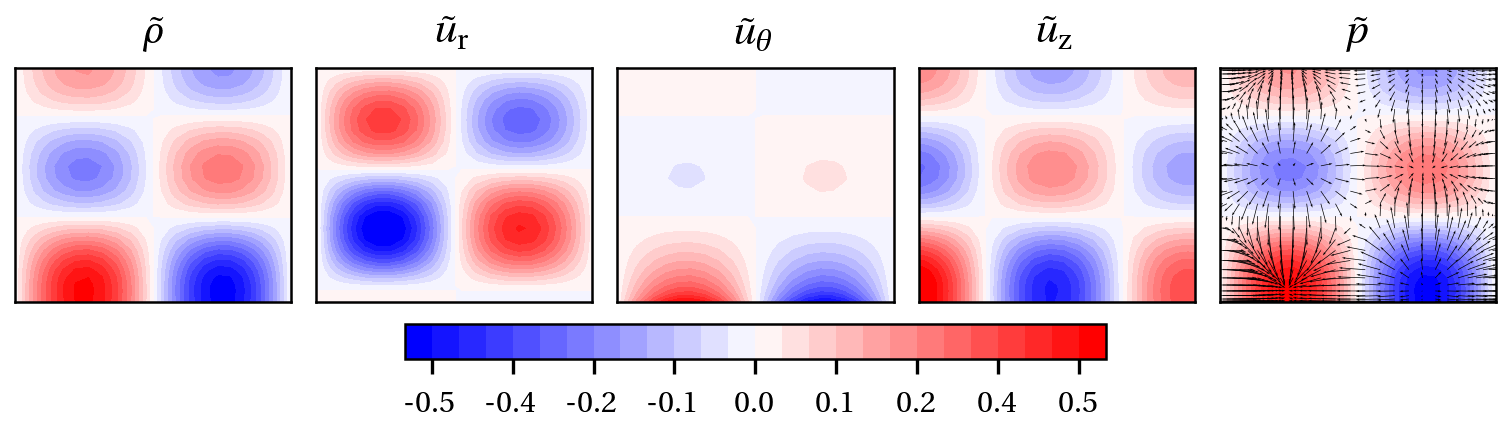

In [53]:
z = pp.data['AxialCoords']
r = pp.data['RadialCoords']
modes_map = plt.get_cmap('bwr')
save_filename = 'test'
modesToPlot = slice(0, 8)


imode = 6
mode = pp.eigenfields[imode]
rs = mode.eigenfrequency.real
df = mode.eigenfrequency.imag

set_thesis_style()
fig, axs = create_figure(fraction=1.00, aspect_ratio=0.7, subplots=(1, 5))
axs = axs.flatten()

titles = [
    r'$\tilde{\rho}$',
    r'$\tilde{u}_{\rm r}$',
    r'$\tilde{u}_{\theta}$',
    r'$\tilde{u}_{\rm z}$',
    r'$\tilde{p}$',
]

fields = [
    mode.eigen_rho,
    mode.eigen_ur,
    mode.eigen_utheta,
    mode.eigen_uz,
    mode.eigen_p,
]


vmin, vmax = -0.5, 0.5

for i, (ax, field, title) in enumerate(zip(axs, fields, titles)):
    cf = ax.contourf(
        z, r, field,
        levels=30,
        cmap=modes_map,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)

    # Keep x-label only for bottom row (if needed adjust condition)
    # ax.set_xlabel(r'$z$')
    ax.set_xticks([])
    ax.set_yticks([])

# Create ONE shared colorbar
cbar = fig.colorbar(
    cf,
    ax=axs,
    format='%.1f',
    orientation='horizontal',
    pad=0.08   # increase = move further away
)

ax.quiver(
        z[1:-1], r[1:-1], mode.eigen_uz[1:-1], mode.eigen_ur[1:-1],
        angles='xy', scale_units='xy', scale=2, width=0.0025
    )


# plt.tight_layout()

fig.savefig(
    'pictures/' + save_filename + '_modes_%i_%i_%i.pdf' %
    (pp.nStream, pp.nSpan, imode),
)




In [54]:
with open('analytical/analytical_eigenvalues.pkl', 'rb') as f:
    analytical = pickle.load(f)

analytical

array([ 4934.70314645,  8225.60546442,  8897.0924599 , 11066.50551677,
       12002.26721184, 13057.68685745, 14101.82177312, 14622.32800138,
       16112.82009757, 17035.44273414, 17273.85569656, 17732.17219049,
       18485.00421256, 20143.85420967, 20447.22997637, 20466.89373747,
       21764.66628178, 23101.03389415, 23770.68846678, 26323.53575687])

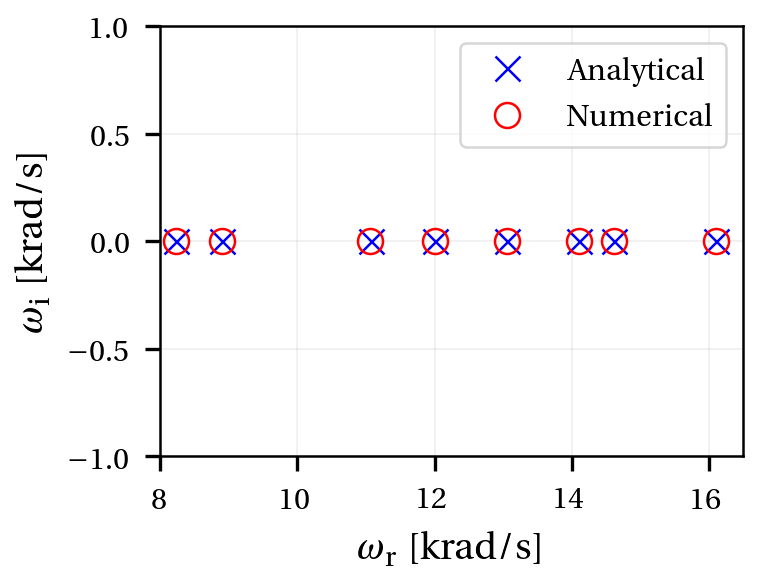

In [55]:
fig, ax = create_figure(fraction=0.5, aspect_ratio=1.3, subplots=(1,1))
ax.plot(analytical/1e3, analytical*0, 'x', mfc='none', ms=6, label='Analytical', c='blue')

# modes 3 and 4 are spurious
eigs = pp.data['Eigenfrequencies']
for ii,eig in enumerate(eigs):
    if ii == 0:
        ax.plot(eig.real/1e3, eig.imag/1e3, 'o', mfc='none', ms=6, label=r'Numerical', c='red')
    elif ii!=3 and ii!=4:
        ax.plot(eig.real/1e3, eig.imag/1e3, 'o', mfc='none', ms=6, c='red')
ax.legend()
ax.grid(alpha=0.2)
ax.set_xlim([8, 16.5])
ax.set_ylim([-1, 1])
ax.set_xlabel(r'$\omega_{\rm r}$ [krad/s]')
ax.set_ylabel(r'$\omega_{\rm i}$ [krad/s]')
fig.savefig('pictures/circularDuct_eigenvalueMap.pdf')